In [1]:
# We were forced to restart with new design and new plan for abstraction
# streamline the bridge between prior knowledge and task processing and solution
# ARCSolver starts with: 1) dimensionality 2) background 3) value_list 4) value_map
#                        2) deductive unsupervised classification of a task according to logical screening: saver0
#                        3) the above MUST represent all tasks uniformly and used to encode the task in a form that
#                           the machine can understand

In [1]:
from taskManagerV02 import *

In [2]:
def print_arrays(case_num):
    #print(tt[case_num]['train'])
    plot_task(tt[case_num])
    this_task = TaskManager(tt[case_num])
    this_task.brief_task()
    return this_task

In [3]:
from pathlib import Path
data_path = Path('/Users/hassanshallal/Desktop/abstract_reasoning_dataset/abstraction-and-reasoning-challenge/')
training_path = data_path / 'training'
tt = load_set(training_path)

In [5]:
# we have none_deductive = [44, 49, 101, 111, 139, 164, 203, 265, 313] of none deductive_0 and there is no problem with our logic

In [ ]:
# coding mechanism is not consistent, there is something we're missing on
# just make sure your encoded nonbg is in couple_value_map values which are sets, so, you need to merge them

# today_analysis_05142020 = []
# all_problem_statements = []
# for n in range(len(tt)):
#     print(n)
#     plot_task(tt[n])
#     this_task = TaskManager(tt[n])
#     this_task.brief_task()
#     today_analysis_05142020.append(this_task)
#     all_problem_statements.append(this_task.problem_statements)
# serialize(today_analysis_05142020, 'assets/today_analysis_05142020')

In [4]:
today_analysis_05142020 = load_serialized('assets/today_analysis_05142020')

In [5]:
len(today_analysis_05142020)

400

In [6]:
coding_situation = {}
coding_situation[0] = []
coding_situation[1] = []
coding_situation[2] = []
for n in range(len(today_analysis_05142020)):
    if len(today_analysis_05142020[n].problem_statements) == 0:
        coding_situation[0].append(n)
    elif type(today_analysis_05142020[n].problem_statements[0]) == tuple:
        coding_situation[1].append(n)
    elif type(today_analysis_05142020[n].problem_statements[0]) == list:
        coding_situation[2].append(n)
        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))

# taking similar_dim and global_bg (all inputs and outputs):
# 0  :  213 : not coded
# 1  :  55  : one code found
# 2  :  132 : multiple codes were found

# taking similar_dim and input_global_bg (only inputs):
# 0  :  186
# 1  :  61
# 2  :  153

# it turns out our coder is actually doing  a better job, the above shows thatwe vave one coding for 133 tasks
# 0  :  186
# 1  :  142
# 2  :  72 (9 cases with None deductive_coder0, very complicated yet correctly percieved)

0  :  186
1  :  142
2  :  72


In [7]:
deductive_coder1_to_tokenized = {}
tokenized_to_deductive_coder1 = {}
for n in coding_situation[1]:
    this_task = today_analysis_05142020[n]
    if this_task.deductive_coder1 != None:
        this_task_deductive_coder1 = str(this_task.deductive_coder1).replace('[', '').replace(']', '')
    else:
        this_task_deductive_coder1 = str(None)
        
    if len(this_task.problem_statements) == 0:
        this_task_tokenized = str(None)
    else:
        this_task_tokenized = str(this_task.problem_statements).replace('[', '').replace(']', '')
        
    if this_task_deductive_coder1 not in deductive_coder1_to_tokenized.keys():
        deductive_coder1_to_tokenized[this_task_deductive_coder1] = set()
    deductive_coder1_to_tokenized[this_task_deductive_coder1].add(this_task_tokenized)
    
    if this_task_tokenized not in tokenized_to_deductive_coder1.keys():
        tokenized_to_deductive_coder1[this_task_tokenized] = set()
    tokenized_to_deductive_coder1[this_task_tokenized].add(this_task_deductive_coder1)

print(len(deductive_coder1_to_tokenized), len(tokenized_to_deductive_coder1))

15 28


In [12]:
coder_1_options = sorted(list((deductive_coder1_to_tokenized.keys())))
tokenized_options = sorted(list(tokenized_to_deductive_coder1.keys()))

In [17]:
coder_1_options

["'bg_C', 'bg_S'",
 "'bg_C', 'bg_S', 'nonbg_C_bg'",
 "'bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg', 'nonbg_S'",
 "'bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S'",
 "'bg_C', 'bg_S', 'nonbg_C_nonbg'",
 "'bg_C', 'bg_S', 'nonbg_C_nonbg', 'nonbg_S'",
 "'bg_C', 'bg_S', 'nonbg_S'",
 "'bg_C', 'nonbg_C_nonbg', 'nonbg_S'",
 "'bg_C', 'nonbg_S'",
 "'bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg'",
 "'bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg', 'nonbg_S'",
 "'bg_S', 'nonbg_C_bg', 'nonbg_S'",
 "'bg_S', 'nonbg_C_nonbg'",
 "'bg_S', 'nonbg_C_nonbg', 'nonbg_S'",
 'None']

In [16]:
tokenized_options

["('bg', 'nonbg0')",
 "('bg', 'nonbg0'), ('bg', 'nonbg1')",
 "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2')",
 "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('bg', 'nonbg3')",
 "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('bg', 'nonbg3'), ('bg', 'nonbg4')",
 "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('bg', 'nonbg3'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg'), ('nonbg3', 'bg')",
 "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg')",
 "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg')",
 "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg')",
 "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg1', 'nonbg0')",
 "('bg', 'nonbg0'), ('nonbg0', 'bg')",
 "('bg', 'nonbg0'), ('nonbg0', 'nonbg1')",
 "('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'nonbg1')",
 "('bg', 'nonbg1'), ('nonbg0', 'bg')",
 "('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg0', 'nonbg1')",
 "('bg', 'nonbg1'), (

In [75]:
# for key in deductive_coder1_to_tokenized.keys():
#     print(key, len(deductive_coder1_to_tokenized[key]))
#     print('=====')
#     print(deductive_coder1_to_tokenized[key])
#     print('--------------------------------')

In [76]:
# for key in tokenized_to_deductive_coder1.keys():
#     print(key, len(tokenized_to_deductive_coder1[key]))
#     print('=====')
#     print(tokenized_to_deductive_coder1[key])
#     print('--------------------------------')

In [100]:
#tokenized_to_deductive_coder1

In [88]:
tokenized_options = sorted(list(tokenized_to_deductive_coder1.keys()))
len(tokenized_options)

28

In [ ]:
# alright, I think the DSL is encoded in the problem graph that offers anchor cells and should be 
# passed to an interpreter on the runtime class that extracts sets of disjoints and expose them to a  series
# of tests deterministically first and may be opportunistically latter.

# inductive recieve raw data and problem graph along with color-to-token and token-to-color situation
# insuctive can then decide which sets of coordinates represent disjoint in each couple, the system
# must start with a conservative mindset so as to accept a solution if and only of it solves all the sets
# correctly and on all couples, otherwise get current solution and current misses.

# There is really no space for a lot of code, there must be a way for the solver to decide on the runtime which
# procedure to go through and how to mangage as much ambiguity at this point as possible.

In [4]:
cases_of_current_interest = [1, 250, 80, 94, 257, 138, 254, 277, 170, 355, 245, 334, 186, 124, 127, 260, 29, 43, 269,
                            52, 352, 7, 77, 121, 153, 389, 96, 195, 278, 293]   

1


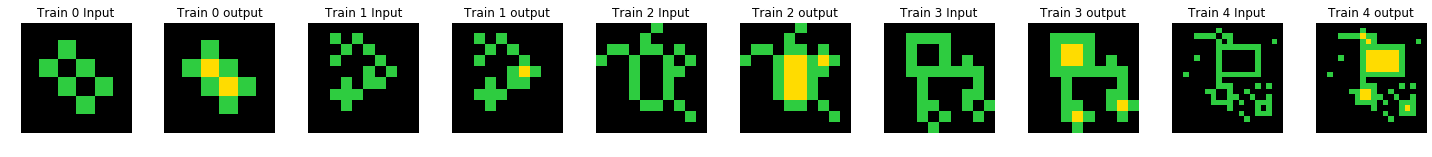

is_similar_dim:  True
input_dims info:  [(6, 20, 14), (6, 20, 14)]
output_dims info:  [(6, 20, 14), (6, 20, 14)]
traininputs_vals:  [[0, 3], [0, 3], [0, 3], [0, 3], [0, 3]]
trainoutputs_vals:  [[0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4]]
couple_val_map:  [{0: {4}}, {0: {4}}, {0: {4}}, {0: {4}}, {0: {4}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {4}}
information about tokenization:
color_to_tokens:  {0: 'bg', 4: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 4}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (3, 3)]
250


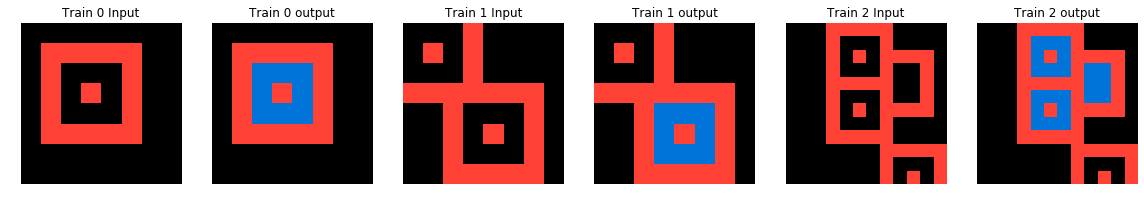

is_similar_dim:  True
input_dims info:  [(8, 12, 4), (8, 12, 4)]
output_dims info:  [(8, 12, 4), (8, 12, 4)]
traininputs_vals:  [[0, 2], [0, 2], [0, 2]]
trainoutputs_vals:  [[0, 1, 2], [0, 1, 2], [0, 1, 2]]
couple_val_map:  [{0: {1}}, {0: {1}}, {0: {1}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {1}}
information about tokenization:
color_to_tokens:  {0: 'bg', 1: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 1}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2)]
80


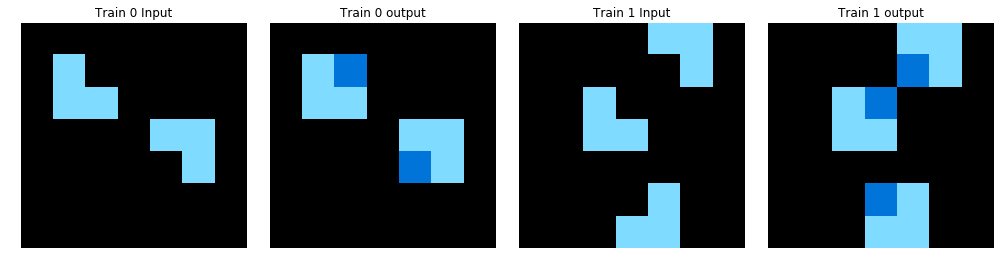

is_similar_dim:  True
input_dims info:  [(7, 7, 0), (7, 7, 0)]
output_dims info:  [(7, 7, 0), (7, 7, 0)]
traininputs_vals:  [[0, 8], [0, 8]]
trainoutputs_vals:  [[0, 1, 8], [0, 1, 8]]
couple_val_map:  [{0: {1}}, {0: {1}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {1}}
information about tokenization:
color_to_tokens:  {0: 'bg', 1: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 1}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (8, 8)]
94


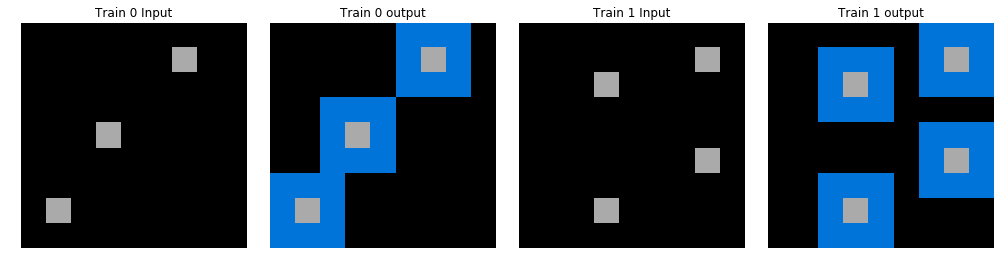

is_similar_dim:  True
input_dims info:  [(9, 9, 0), (9, 9, 0)]
output_dims info:  [(9, 9, 0), (9, 9, 0)]
traininputs_vals:  [[0, 5], [0, 5]]
trainoutputs_vals:  [[0, 1, 5], [0, 1, 5]]
couple_val_map:  [{0: {1}}, {0: {1}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {1}}
information about tokenization:
color_to_tokens:  {0: 'bg', 1: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 1}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (5, 5)]
257


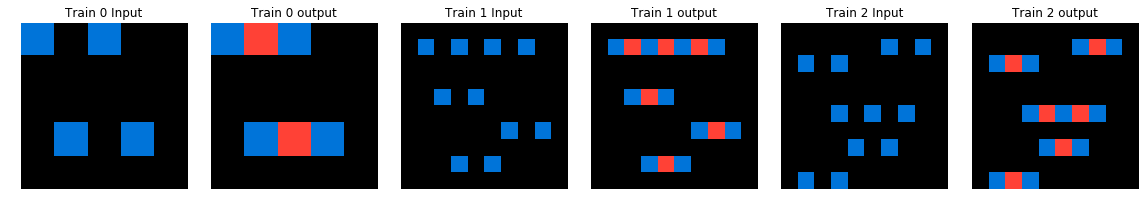

is_similar_dim:  True
input_dims info:  [(5, 10, 5), (5, 10, 5)]
output_dims info:  [(5, 10, 5), (5, 10, 5)]
traininputs_vals:  [[0, 1], [0, 1], [0, 1]]
trainoutputs_vals:  [[0, 1, 2], [0, 1, 2], [0, 1, 2]]
couple_val_map:  [{0: {2}}, {0: {2}}, {0: {2}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {2}}
information about tokenization:
color_to_tokens:  {0: 'bg', 2: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 2}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), (1, 1), ('bg', 'bg')]
138


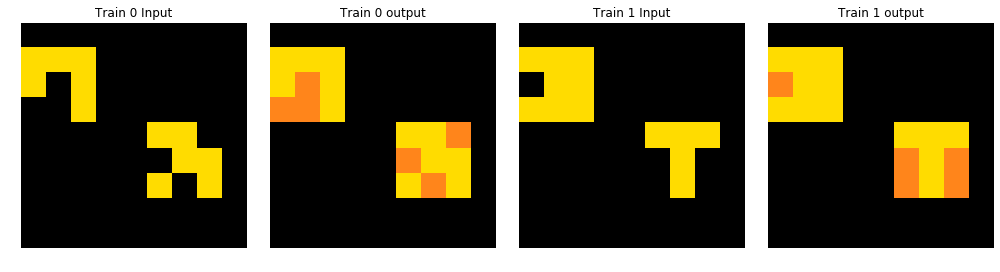

is_similar_dim:  True
input_dims info:  [(9, 9, 0), (9, 9, 0)]
output_dims info:  [(9, 9, 0), (9, 9, 0)]
traininputs_vals:  [[0, 4], [0, 4]]
trainoutputs_vals:  [[0, 4, 7], [0, 4, 7]]
couple_val_map:  [{0: {7}}, {0: {7}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {7}}
information about tokenization:
color_to_tokens:  {0: 'bg', 7: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 7}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (4, 4)]
254


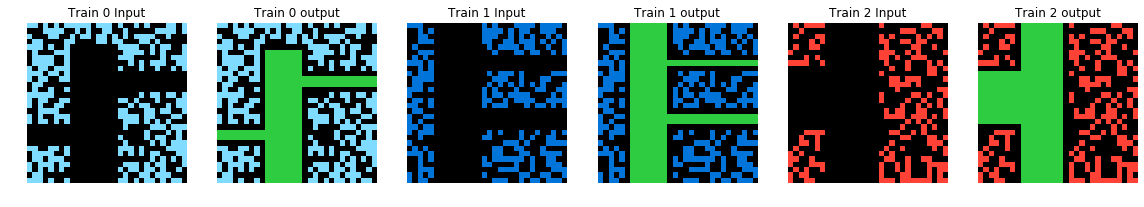

is_similar_dim:  True
input_dims info:  [(30, 30, 0), (30, 30, 0)]
output_dims info:  [(30, 30, 0), (30, 30, 0)]
traininputs_vals:  [[0, 8], [0, 1], [0, 2]]
trainoutputs_vals:  [[0, 3, 8], [0, 1, 3], [0, 2, 3]]
couple_val_map:  [{0: {3}}, {0: {3}}, {0: {3}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {3}}
information about tokenization:
color_to_tokens:  {0: 'bg', 3: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 3}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg')]
277


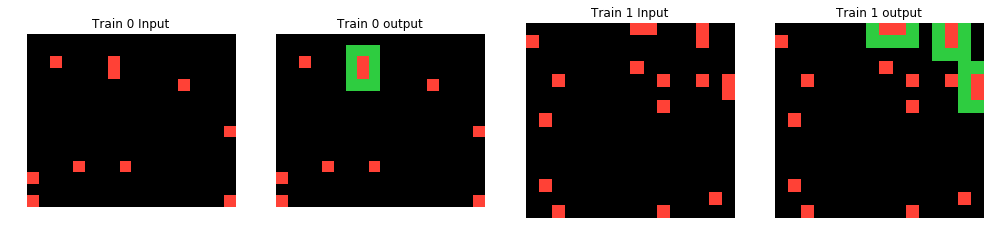

is_similar_dim:  True
input_dims info:  [(15, 15, 0), (16, 18, 2)]
output_dims info:  [(15, 15, 0), (16, 18, 2)]
traininputs_vals:  [[0, 2], [0, 2]]
trainoutputs_vals:  [[0, 2, 3], [0, 2, 3]]
couple_val_map:  [{0: {3}}, {0: {3}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {3}}
information about tokenization:
color_to_tokens:  {0: 'bg', 3: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 3}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2)]
170


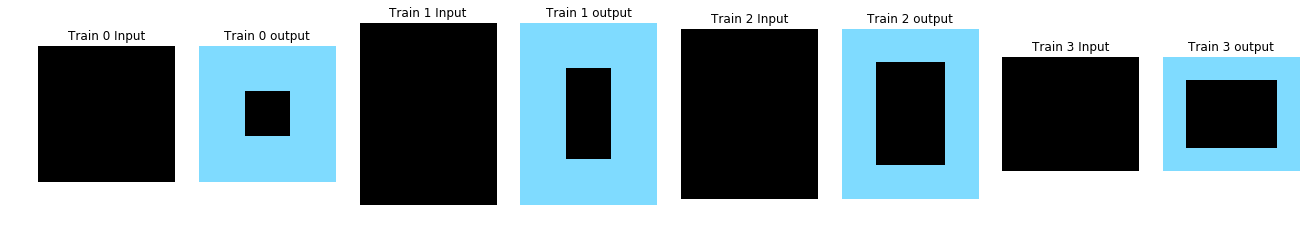

is_similar_dim:  True
input_dims info:  [(3, 5, 2), (3, 6, 3)]
output_dims info:  [(3, 5, 2), (3, 6, 3)]
traininputs_vals:  [[0], [0], [0], [0]]
trainoutputs_vals:  [[0, 8], [0, 8], [0, 8], [0, 8]]
couple_val_map:  [{0: {8}}, {0: {8}}, {0: {8}}, {0: {8}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S']
deductive_coder1:  ['bg_C', 'bg_S']
global_value_map:  {0: {8}}
information about tokenization:
color_to_tokens:  {0: 'bg', 8: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 8}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg')]
355


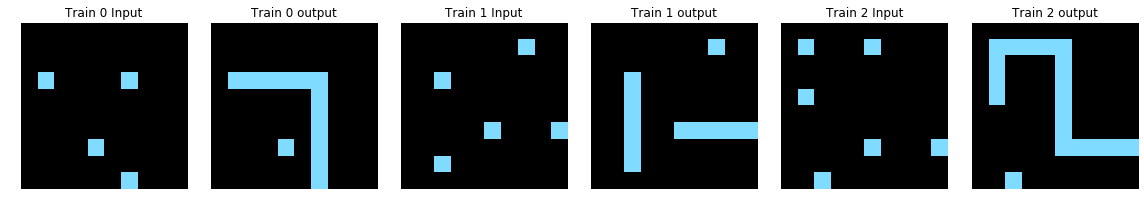

is_similar_dim:  True
input_dims info:  [(10, 10, 0), (10, 10, 0)]
output_dims info:  [(10, 10, 0), (10, 10, 0)]
traininputs_vals:  [[0, 8], [0, 8], [0, 8]]
trainoutputs_vals:  [[0, 8], [0, 8], [0, 8]]
couple_val_map:  [{0: {8}}, {0: {8}}, {0: {8}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {8}}
information about tokenization:
color_to_tokens:  {0: 'bg', 8: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 8}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
245


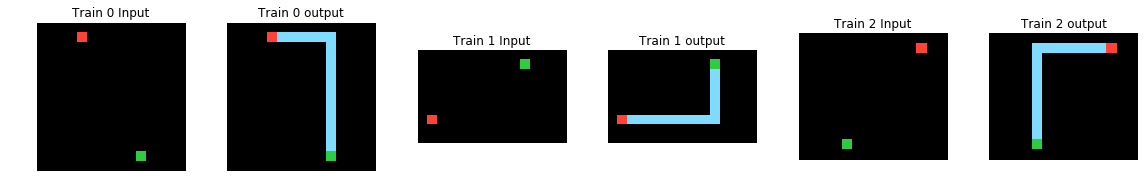

is_similar_dim:  True
input_dims info:  [(10, 15, 5), (14, 16, 2)]
output_dims info:  [(10, 15, 5), (14, 16, 2)]
traininputs_vals:  [[0, 2, 3], [0, 2, 3], [0, 2, 3]]
trainoutputs_vals:  [[0, 2, 3, 8], [0, 2, 3, 8], [0, 2, 3, 8]]
couple_val_map:  [{0: {8}}, {0: {8}}, {0: {8}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {8}}
information about tokenization:
color_to_tokens:  {0: 'bg', 8: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 8}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2), (3, 3)]
334


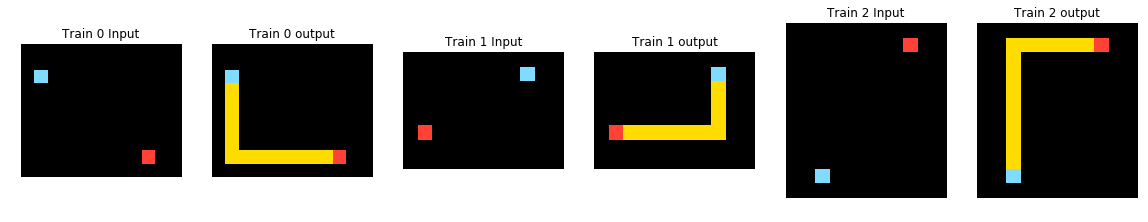

is_similar_dim:  True
input_dims info:  [(8, 12, 4), (11, 12, 1)]
output_dims info:  [(8, 12, 4), (11, 12, 1)]
traininputs_vals:  [[0, 2, 8], [0, 2, 8], [0, 2, 8]]
trainoutputs_vals:  [[0, 2, 4, 8], [0, 2, 4, 8], [0, 2, 4, 8]]
couple_val_map:  [{0: {4}}, {0: {4}}, {0: {4}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {0: {4}}
information about tokenization:
color_to_tokens:  {0: 'bg', 4: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 4}
problem_statements:  [('bg', 'nonbg0')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (8, 8), (2, 2)]
186


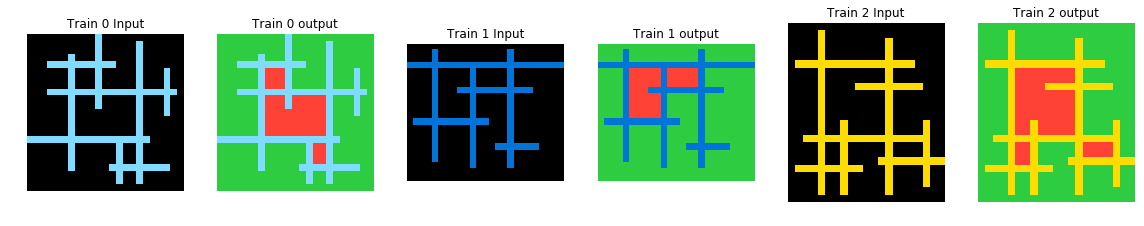

is_similar_dim:  True
input_dims info:  [(22, 24, 2), (21, 25, 4)]
output_dims info:  [(22, 24, 2), (21, 25, 4)]
traininputs_vals:  [[0, 8], [0, 1], [0, 4]]
trainoutputs_vals:  [[2, 3, 8], [1, 2, 3], [2, 3, 4]]
couple_val_map:  [{0: {2, 3}}, {0: {2, 3}}, {0: {2, 3}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'nonbg_S']
global_value_map:  {0: {2, 3}}
information about tokenization:
color_to_tokens:  {0: 'bg', 2: 'nonbg0', 3: 'nonbg1'}
token_to_colors:  {'bg': 0, 'nonbg0': 2, 'nonbg1': 3}
problem_statements:  [('bg', 'nonbg0'), ('bg', 'nonbg1')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1')]
124


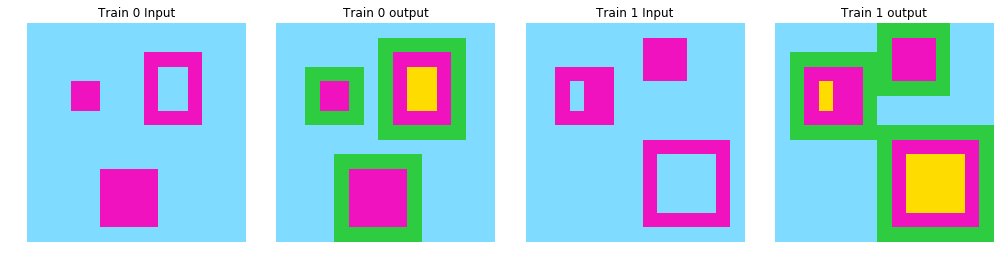

is_similar_dim:  True
input_dims info:  [(15, 15, 0), (15, 15, 0)]
output_dims info:  [(15, 15, 0), (15, 15, 0)]
traininputs_vals:  [[6, 8], [6, 8]]
trainoutputs_vals:  [[3, 4, 6, 8], [3, 4, 6, 8]]
couple_val_map:  [{8: {3, 4}}, {8: {3, 4}}]
global_bg:  True
bg:  8
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_S']
global_value_map:  {8: {3, 4}}
information about tokenization:
color_to_tokens:  {8: 'bg', 3: 'nonbg0', 4: 'nonbg1'}
token_to_colors:  {'bg': 8, 'nonbg0': 3, 'nonbg1': 4}
problem_statements:  [('bg', 'nonbg0'), ('bg', 'nonbg1')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'bg'), (6, 6)]
127


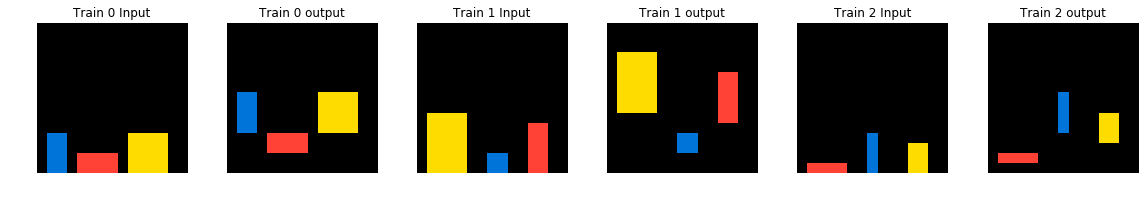

is_similar_dim:  True
input_dims info:  [(15, 15, 0), (15, 15, 0)]
output_dims info:  [(15, 15, 0), (15, 15, 0)]
traininputs_vals:  [[0, 1, 2, 4], [0, 1, 2, 4], [0, 1, 2, 4]]
trainoutputs_vals:  [[0, 1, 2, 4], [0, 1, 2, 4], [0, 1, 2, 4]]
couple_val_map:  [{0: {1, 2, 4}, 1: {0}, 4: {0}, 2: {0}}, {0: {1, 2, 4}, 4: {0}, 2: {0}, 1: {0}}, {0: {1, 2, 4}, 1: {0}, 4: {0}, 2: {0}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg']
global_value_map:  {0: {1, 2, 4}, 1: {0}, 4: {0}, 2: {0}}
information about tokenization:
color_to_tokens:  {0: 'bg', 1: 'nonbg0', 2: 'nonbg1', 4: 'nonbg2'}
token_to_colors:  {'bg': 0, 'nonbg0': 1, 'nonbg1': 2, 'nonbg2': 4}
problem_statements:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg'), ('bg', 'bg')]
260


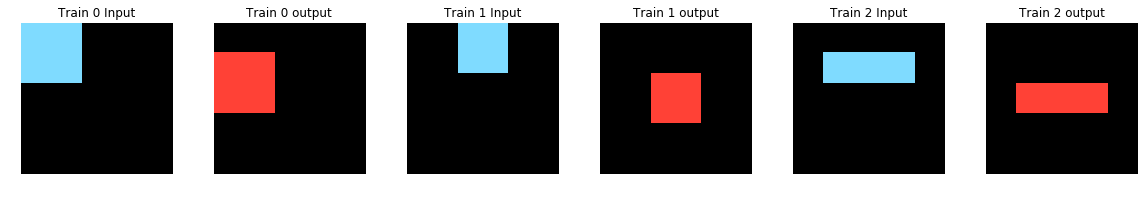

is_similar_dim:  True
input_dims info:  [(3, 5, 2), (3, 5, 2)]
output_dims info:  [(3, 5, 2), (3, 5, 2)]
traininputs_vals:  [[0, 8], [0, 8], [0, 8]]
trainoutputs_vals:  [[0, 2], [0, 2], [0, 2]]
couple_val_map:  [{8: {0, 2}, 0: {2}}, {8: {0}, 0: {2}}, {8: {0}, 0: {2}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C']
deductive_coder1:  None
global_value_map:  {8: {0, 2}, 0: {2}}
information about tokenization:
color_to_tokens:  {0: 'bg', 8: 'nonbg0', 2: 'nonbg1'}
token_to_colors:  {'bg': 0, 'nonbg0': 8, 'nonbg1': 2}
problem_statements:  [('bg', 'nonbg1'), ('nonbg0', 'bg')]
problem_graph:  [('bg', 'nonbg1'), ('nonbg0', 'bg'), ('bg', 'bg')]
29


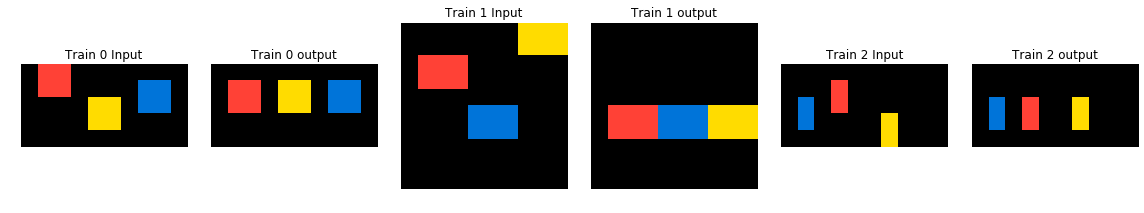

is_similar_dim:  True
input_dims info:  [(5, 10, 5), (10, 10, 0)]
output_dims info:  [(5, 10, 5), (10, 10, 0)]
traininputs_vals:  [[0, 1, 2, 4], [0, 1, 2, 4], [0, 1, 2, 4]]
trainoutputs_vals:  [[0, 1, 2, 4], [0, 1, 2, 4], [0, 1, 2, 4]]
couple_val_map:  [{2: {0}, 0: {2, 4}, 4: {0}}, {4: {0}, 2: {0}, 0: {2, 4}}, {2: {0}, 0: {2, 4}, 4: {0}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {2: {0}, 0: {2, 4}, 4: {0}}
information about tokenization:
color_to_tokens:  {0: 'bg', 2: 'nonbg0', 4: 'nonbg1'}
token_to_colors:  {'bg': 0, 'nonbg0': 2, 'nonbg1': 4}
problem_statements:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (1, 1), ('nonbg1', 'nonbg1')]
43


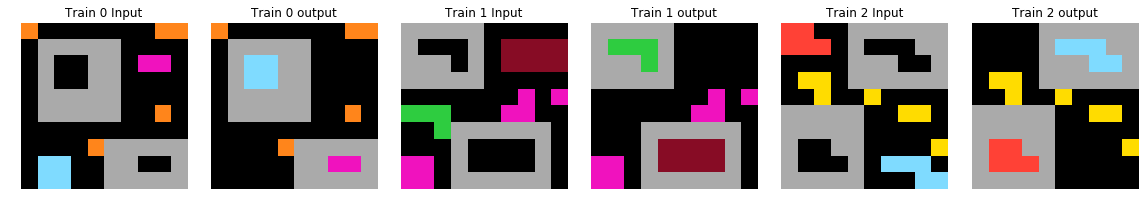

is_similar_dim:  True
input_dims info:  [(10, 10, 0), (10, 10, 0)]
output_dims info:  [(10, 10, 0), (10, 10, 0)]
traininputs_vals:  [[0, 5, 6, 7, 8], [0, 3, 5, 6, 9], [0, 2, 4, 5, 8]]
trainoutputs_vals:  [[0, 5, 6, 7, 8], [0, 3, 5, 6, 9], [0, 2, 4, 5, 8]]
couple_val_map:  [{0: {8, 6}, 6: {0}, 8: {0}}, {0: {9, 3}, 9: {0}, 3: {0}}, {2: {0}, 0: {8, 2}, 8: {0}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {0: {2, 3, 6, 8, 9}, 6: {0}, 8: {0}, 9: {0}, 3: {0}, 2: {0}}
information about tokenization:
color_to_tokens:  {0: 'bg', 6: 'nonbg0', 8: 'nonbg1'}
token_to_colors:  {'bg': 0, 'nonbg0': 6, 'nonbg1': 8}
problem_statements:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('bg', 'bg'), (5, 5), ('nonbg0', 'nonbg0')]
269


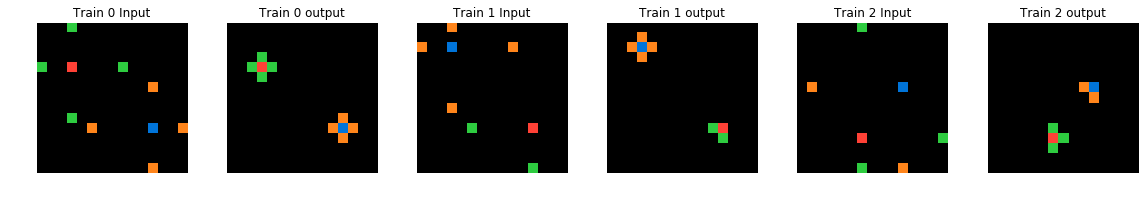

is_similar_dim:  True
input_dims info:  [(15, 15, 0), (15, 15, 0)]
output_dims info:  [(15, 15, 0), (15, 15, 0)]
traininputs_vals:  [[0, 1, 2, 3, 7], [0, 1, 2, 3, 7], [0, 1, 2, 3, 7]]
trainoutputs_vals:  [[0, 1, 2, 3, 7], [0, 1, 2, 3, 7], [0, 1, 2, 3, 7]]
couple_val_map:  [{3: {0}, 0: {3, 7}, 7: {0}}, {7: {0}, 0: {3, 7}, 3: {0}}, {3: {0}, 7: {0}, 0: {3, 7}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {3: {0}, 0: {3, 7}, 7: {0}}
information about tokenization:
color_to_tokens:  {0: 'bg', 3: 'nonbg0', 7: 'nonbg1'}
token_to_colors:  {'bg': 0, 'nonbg0': 3, 'nonbg1': 7}
problem_statements:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('bg', 'bg'), (2, 2), (1, 1)]
52


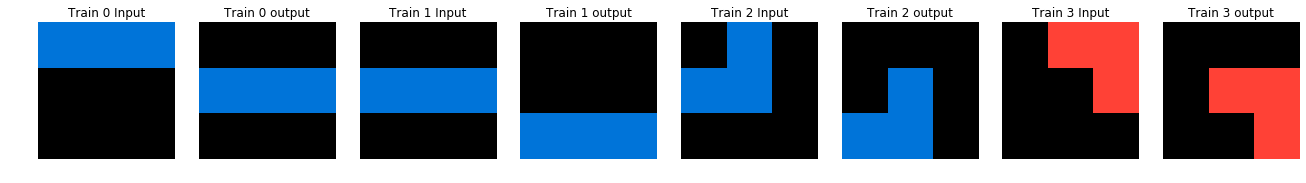

is_similar_dim:  True
input_dims info:  [(3, 3, 0), (3, 3, 0)]
output_dims info:  [(3, 3, 0), (3, 3, 0)]
traininputs_vals:  [[0, 1], [0, 1], [0, 1], [0, 2]]
trainoutputs_vals:  [[0, 1], [0, 1], [0, 1], [0, 2]]
couple_val_map:  [{1: {0}, 0: {1}}, {1: {0}, 0: {1}}, {1: {0}, 0: {1}}, {2: {0}, 0: {2}}]
global_bg:  True
bg:  0
deductive_coder0:  None
deductive_coder1:  None
global_value_map:  {1: {0}, 0: {1, 2}, 2: {0}}
information about tokenization:
color_to_tokens:  {0: 'bg', 1: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 1}
problem_statements:  [('bg', 'nonbg0'), ('nonbg0', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
352


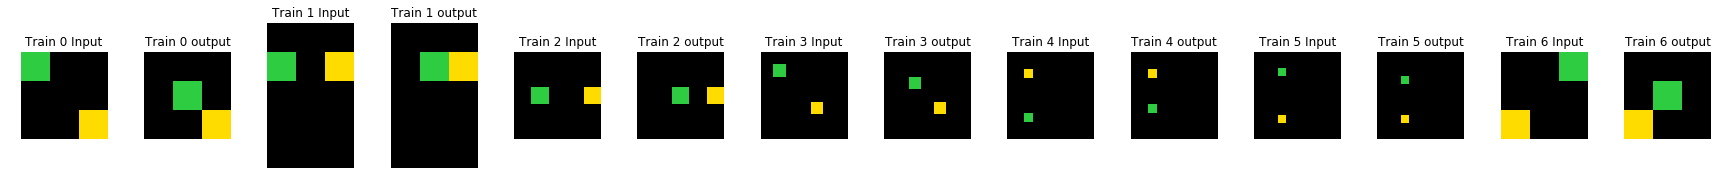

is_similar_dim:  True
input_dims info:  [(3, 11, 8), (3, 11, 8)]
output_dims info:  [(3, 11, 8), (3, 11, 8)]
traininputs_vals:  [[0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4]]
trainoutputs_vals:  [[0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4], [0, 3, 4]]
couple_val_map:  [{3: {0}, 0: {3}}, {3: {0}, 0: {3}}, {3: {0}, 0: {3}}, {3: {0}, 0: {3}}, {0: {3}, 3: {0}}, {3: {0}, 0: {3}}, {3: {0}, 0: {3}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {3: {0}, 0: {3}}
information about tokenization:
color_to_tokens:  {0: 'bg', 3: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 3}
problem_statements:  [('bg', 'nonbg0'), ('nonbg0', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (4, 4)]
7


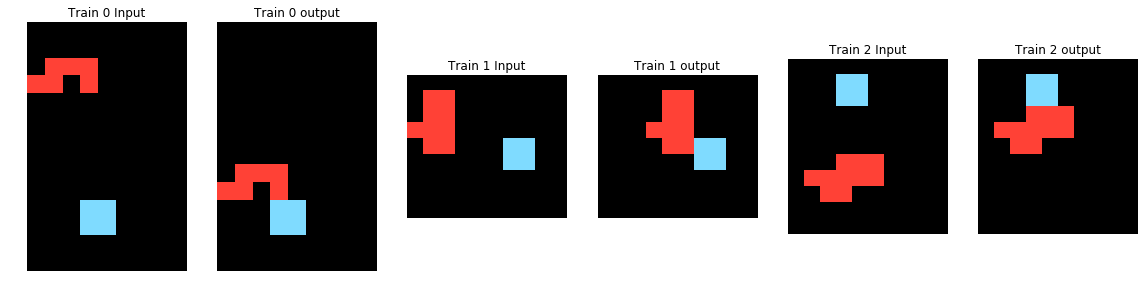

is_similar_dim:  True
input_dims info:  [(9, 14, 5), (9, 10, 1)]
output_dims info:  [(9, 14, 5), (9, 10, 1)]
traininputs_vals:  [[0, 2, 8], [0, 2, 8], [0, 2, 8]]
trainoutputs_vals:  [[0, 2, 8], [0, 2, 8], [0, 2, 8]]
couple_val_map:  [{2: {0}, 0: {2}}, {2: {0}, 0: {2}}, {0: {2}, 2: {0}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {2: {0}, 0: {2}}
information about tokenization:
color_to_tokens:  {0: 'bg', 2: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 2}
problem_statements:  [('bg', 'nonbg0'), ('nonbg0', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (8, 8)]
77


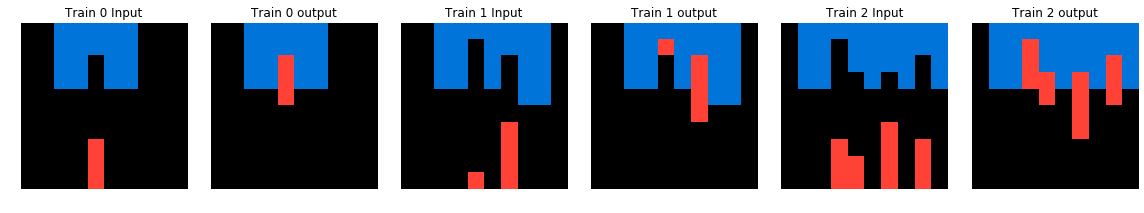

is_similar_dim:  True
input_dims info:  [(10, 10, 0), (10, 10, 0)]
output_dims info:  [(10, 10, 0), (10, 10, 0)]
traininputs_vals:  [[0, 1, 2], [0, 1, 2], [0, 1, 2]]
trainoutputs_vals:  [[0, 1, 2], [0, 1, 2], [0, 1, 2]]
couple_val_map:  [{0: {2}, 2: {0}}, {0: {2}, 2: {0}}, {0: {2}, 2: {0}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {0: {2}, 2: {0}}
information about tokenization:
color_to_tokens:  {0: 'bg', 2: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 2}
problem_statements:  [('bg', 'nonbg0'), ('nonbg0', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (1, 1), ('nonbg0', 'nonbg0')]
121


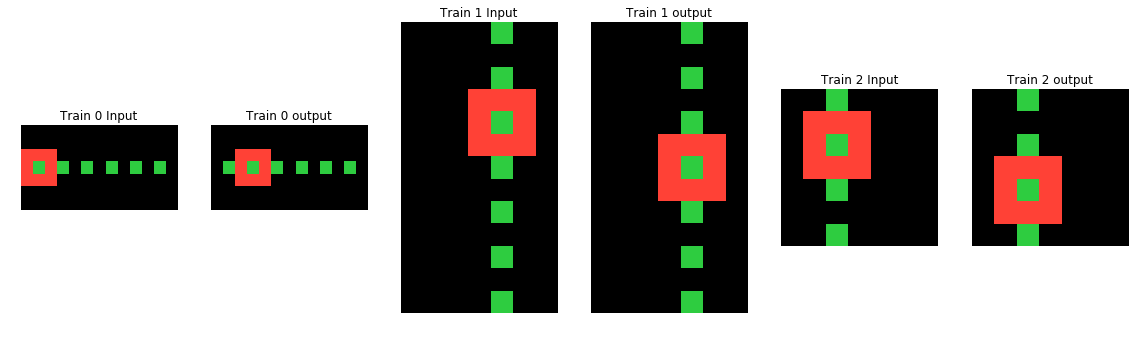

is_similar_dim:  True
input_dims info:  [(7, 13, 6), (7, 13, 6)]
output_dims info:  [(7, 13, 6), (7, 13, 6)]
traininputs_vals:  [[0, 2, 3], [0, 2, 3], [0, 2, 3]]
trainoutputs_vals:  [[0, 2, 3], [0, 2, 3], [0, 2, 3]]
couple_val_map:  [{2: {0}, 0: {2}}, {2: {0}, 0: {2}}, {2: {0}, 0: {2}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {2: {0}, 0: {2}}
information about tokenization:
color_to_tokens:  {0: 'bg', 2: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 2}
problem_statements:  [('bg', 'nonbg0'), ('nonbg0', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (3, 3)]
153


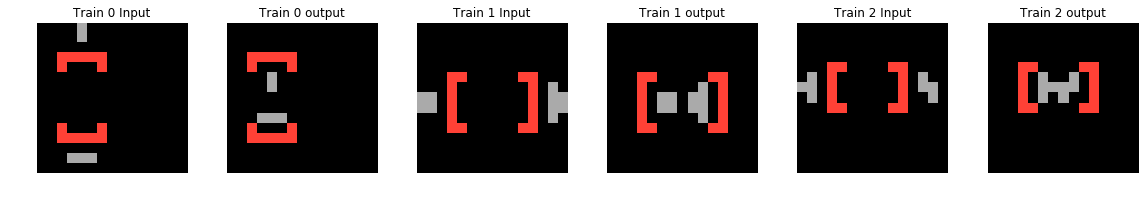

is_similar_dim:  True
input_dims info:  [(15, 15, 0), (15, 15, 0)]
output_dims info:  [(15, 15, 0), (15, 15, 0)]
traininputs_vals:  [[0, 2, 5], [0, 2, 5], [0, 2, 5]]
trainoutputs_vals:  [[0, 2, 5], [0, 2, 5], [0, 2, 5]]
couple_val_map:  [{5: {0}, 0: {5}}, {0: {5}, 5: {0}}, {5: {0}, 0: {5}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {5: {0}, 0: {5}}
information about tokenization:
color_to_tokens:  {0: 'bg', 5: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 5}
problem_statements:  [('bg', 'nonbg0'), ('nonbg0', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (2, 2)]
389


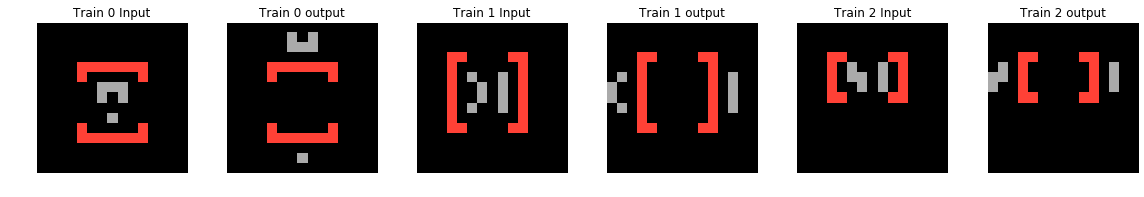

is_similar_dim:  True
input_dims info:  [(15, 15, 0), (15, 15, 0)]
output_dims info:  [(15, 15, 0), (15, 15, 0)]
traininputs_vals:  [[0, 2, 5], [0, 2, 5], [0, 2, 5]]
trainoutputs_vals:  [[0, 2, 5], [0, 2, 5], [0, 2, 5]]
couple_val_map:  [{0: {5}, 5: {0}}, {0: {5}, 5: {0}}, {0: {5}, 5: {0}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {0: {5}, 5: {0}}
information about tokenization:
color_to_tokens:  {0: 'bg', 5: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 5}
problem_statements:  [('bg', 'nonbg0'), ('nonbg0', 'bg')]
problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (2, 2)]
96


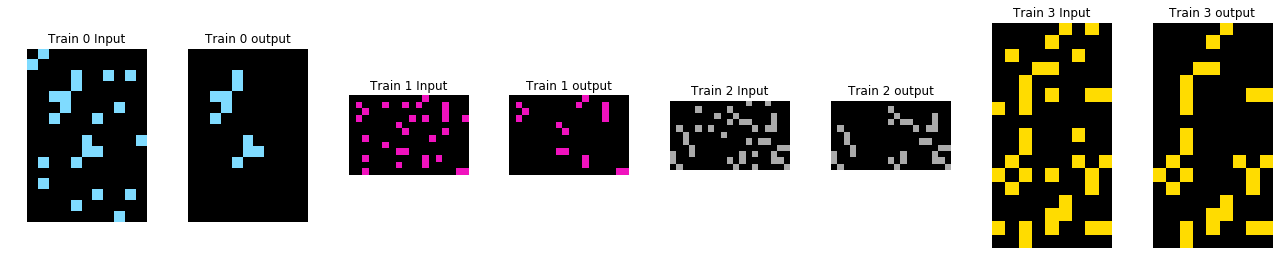

is_similar_dim:  True
input_dims info:  [(11, 17, 6), (9, 19, 10)]
output_dims info:  [(11, 17, 6), (9, 19, 10)]
traininputs_vals:  [[0, 8], [0, 6], [0, 5], [0, 4]]
trainoutputs_vals:  [[0, 8], [0, 6], [0, 5], [0, 4]]
couple_val_map:  [{8: {0}}, {6: {0}}, {5: {0}}, {4: {0}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {8: {0}, 6: {0}, 5: {0}, 4: {0}}
information about tokenization:
color_to_tokens:  {0: 'bg', 8: 'nonbg0'}
token_to_colors:  {'bg': 0, 'nonbg0': 8}
problem_statements:  [('nonbg0', 'bg')]
problem_graph:  [('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
195


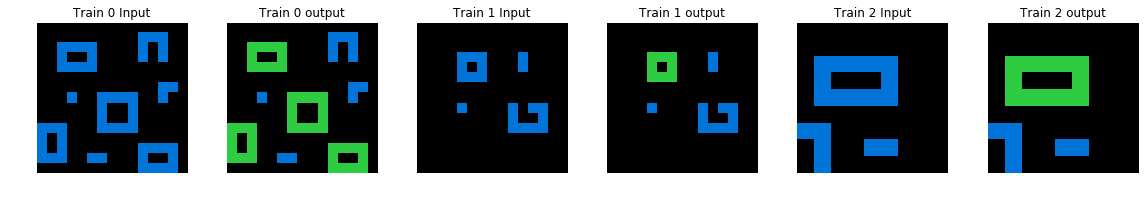

is_similar_dim:  True
input_dims info:  [(9, 15, 6), (9, 15, 6)]
output_dims info:  [(9, 15, 6), (9, 15, 6)]
traininputs_vals:  [[0, 1], [0, 1], [0, 1]]
trainoutputs_vals:  [[0, 1, 3], [0, 1, 3], [0, 1, 3]]
couple_val_map:  [{1: {3}}, {1: {3}}, {1: {3}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_S', 'nonbg_C_nonbg', 'nonbg_S']
global_value_map:  {1: {3}}
information about tokenization:
color_to_tokens:  {0: 'bg', 1: 'nonbg0', 3: 'nonbg1'}
token_to_colors:  {'bg': 0, 'nonbg0': 1, 'nonbg1': 3}
problem_statements:  [('nonbg0', 'nonbg1')]
problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
278


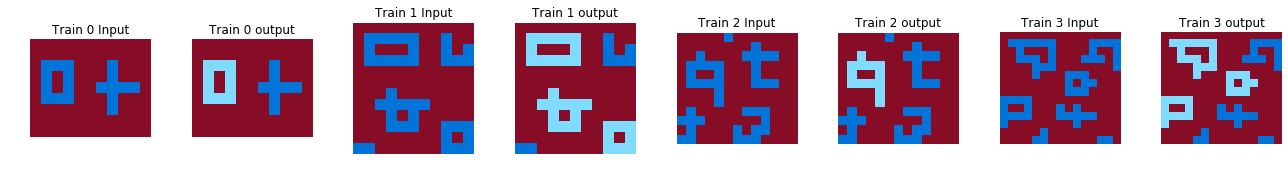

is_similar_dim:  True
input_dims info:  [(9, 14, 5), (11, 15, 4)]
output_dims info:  [(9, 14, 5), (11, 15, 4)]
traininputs_vals:  [[1, 9], [1, 9], [1, 9], [1, 9]]
trainoutputs_vals:  [[1, 8, 9], [1, 8, 9], [1, 8, 9], [1, 8, 9]]
couple_val_map:  [{1: {8}}, {1: {8}}, {1: {8}}, {1: {8}}]
global_bg:  True
bg:  9
deductive_coder0:  ['bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_S', 'nonbg_C_nonbg', 'nonbg_S']
global_value_map:  {1: {8}}
information about tokenization:
color_to_tokens:  {9: 'bg', 1: 'nonbg0', 8: 'nonbg1'}
token_to_colors:  {'bg': 9, 'nonbg0': 1, 'nonbg1': 8}
problem_statements:  [('nonbg0', 'nonbg1')]
problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
293


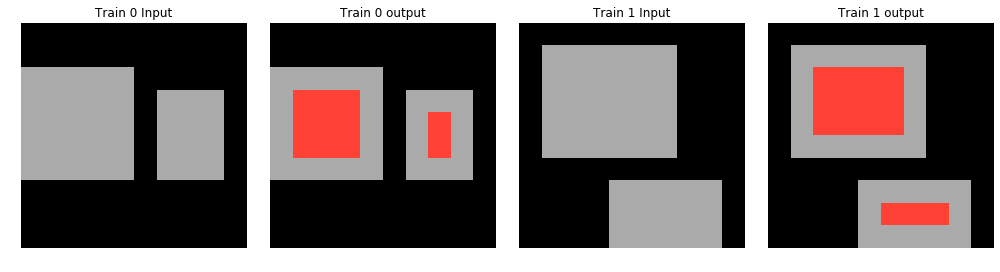

is_similar_dim:  True
input_dims info:  [(10, 10, 0), (10, 10, 0)]
output_dims info:  [(10, 10, 0), (10, 10, 0)]
traininputs_vals:  [[0, 5], [0, 5]]
trainoutputs_vals:  [[0, 2, 5], [0, 2, 5]]
couple_val_map:  [{5: {2}}, {5: {2}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_S', 'nonbg_C_nonbg', 'nonbg_S']
global_value_map:  {5: {2}}
information about tokenization:
color_to_tokens:  {0: 'bg', 5: 'nonbg0', 2: 'nonbg1'}
token_to_colors:  {'bg': 0, 'nonbg0': 5, 'nonbg1': 2}
problem_statements:  [('nonbg0', 'nonbg1')]
problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]


30

In [5]:
# wrong coding: problematic graphs: 52, 96, 192
specific_problem_graphs = []
for n in cases_of_current_interest:
    print(n)
    this_task = TaskManager(tt[n])
    specific_problem_graphs.append(this_task.problem_graph)
    print_arrays(n)
len(specific_problem_graphs)

In [15]:
this_ps = [[('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg0', 'nonbg1')], [('bg', 'nonbg1'), ('nonbg0', 'bg')], [('bg', 'nonbg1'), ('nonbg0', 'bg')]]
len(this_ps)
maxes = 0
maxes_ind = -1

for n in this_ps:
    current_sum = sum([x == n for x in this_ps])
    if current_sum > maxes:
        maxes = current_sum
        maxes_ind = n
maxes, maxes_ind

(2, [('bg', 'nonbg1'), ('nonbg0', 'bg')])

In [17]:
max(list(this_ps), key = this_ps.count) 

[('bg', 'nonbg1'), ('nonbg0', 'bg')]

In [146]:
# We are certainly ready for the inductive tomorrow
# go small layers first, don't bother more difficult cases requiring recursive or iterative approaches

# 90 cases out of the 142 tokenized_options[0] to tokenized_options[4] are among the most difficult ones: includes a lot of creation
#
### tokenized_options[0]: "('bg', 'nonbg0')", 56 cases: {"'bg_C', 'bg_S'", "'bg_C', 'bg_S', 'nonbg_S'"}
#                       this case is ideal to understand using reversible rules from output becuase 
#                       when you see a destruction, you should in principle be able to devise a construction using
#                       the opposite first principle
# Task: 1, 250 the easiest way: output: which nonbg cells change an why? == which bg cells change in the input and why?
#                           "'bg_S', 'nonbg_C', 'nonbg_S'"          "'bg_C', 'bg_S', 'nonbg_S'"
#                                    problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2)]

#  Simple flip from bg_C to nonbg_C and in both cases, you must have a way to extract a question such as?
#               what is the difference between 'bg_C' and bg_S' in input and 
#                       the difference between 'nonbg_C' and 'nonbg_S' in output


# Task 80: bg cells with 3 nonbg neighbours is the one to change any other case don't transpire
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (8, 8)]
# Task 94: bg cells with 1 nonbg neighbours is the one to change any other case don't transpire
# Task 257: bg cells with 2 nonbg neighbours is the one to change any other case don't transpire
# Task 138: bg cell with 1, 2, or 3 nonbg neighbours awitch (at least one neigboour)
# Task 254: ongl bg with no neighbours at all change
                # problem_graph: [('bg', 'nonbg0'), (8, 8), ('bg', 'bg'), (1, 1), (2, 2)]
    
# An induction module must offer easy checks such as red versus blue | (can work on output to input but not vice versa)
#                                     captured versus non captured? |  (works on both input and output)
#                                     has neighbours versus has no neighbour? (can work on input to output but can't bring you from output )
#                                     has 3 neighbours versus any other scenario?


# Task 277 is the opposite of finding our what has already been captured, it is the process of finding out
# which one to capture? in this task, you capture any red cells with at least one neighbour?
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2)]

# Task 170 ['bg_C', 'bg_S'] is your base case as far as creation, you have to code it?
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg')]

# Task 355, then 245, 334 is the basic as far as coordinate based line creation is
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2), (3, 3)]
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (8, 8), (2, 2)]
            

#### tokenized_options[1]: "('bg', 'nonbg0'), ('bg', 'nonbg1')", 22 cases: {"'bg_C', 'bg_S', 'nonbg_S'", "'bg_C', 'nonbg_S'"}
# Task 186: "'bg_C', 'nonbg_S'": captured changes differently than noncaptured
            # problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), (8, 8), (1, 1), (4, 4)]

# Task 124: "'bg_C', 'bg_S', 'nonbg_S'": captured + capturing (combination we talk about)
            # problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'bg'), (6, 6)]
    
# Others are more difficult creation, machine not there yet I guess
#### tokenized_options[2]: "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2')", 7 cases: {"'bg_C', 'bg_S', 'nonbg_S'", "'bg_C', 'nonbg_S'"}
# more progression of the previous ones, more diversity in creation
#### tokenized_options[3]: "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('bg', 'nonbg3')": 3 cases {"'bg_C', 'bg_S', 'nonbg_S'"}
#### tokenized_options[4]: "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('bg', 'nonbg3'), ('bg', 'nonbg4')": 2 cases {"'bg_C', 'bg_S', 'nonbg_S'"}


# tokenized_options[6]
# Task 127, 260: basic movement: [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg')]
#                           ['bg_C', 'bg_S', 'nonbg_C_bg']
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg'), ('bg', 'bg')]


# tokenized_options[8]
# Task 29, 43, 269: selective movement: [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg')]
#                           ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S'] nonbg_S don't move, it is the anchor as far as position
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), 
#                  ('bg', 'bg'), ('nonbg0', 'nonbg0'), (1, 1), ('nonbg1', 'nonbg1')]
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), 
#                  (7, 7), ('bg', 'bg'), (5, 5), ('nonbg0', 'nonbg0'), (4, 4)]
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), 
#                  ('bg', 'bg'), (2, 2), (1, 1)]

# tokenized_options[10]: 11 case : [('bg', 'nonbg0'), ('nonbg0', 'bg')], ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
# Transitions: 52: most basic movement, just one row down!
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (2, 2)] # wrong, 2 is in fact nonbg0
#              352: green towards yellow!
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (4, 4)]
#             7, 77, 121: movements influneced by coordinate of an attracting object
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (8, 8)]
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (1, 1), ('nonbg0', 'nonbg0')]
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (3, 3)]

#             153 and 389 are mirror images of each others: same problem_graph
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (2, 2)]
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (2, 2)]


# tokenized_options[17]: 2 cases: [('nonbg0', 'bg')],  ['bg_S', 'nonbg_C_bg', 'nonbg_S']
#                        Task 96: nonbg with at least one nonbg neighbours survive
# problem_graph:  [('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (6, 6), (5, 5), (4, 4)] # wrong because 4, 5, 6 are all nonbg0 
#                        Task 192: nonbg with less than two nonbg neghbours disappear
# problem_graph:  [('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (6, 6), (5, 5)] # wrong because 5, 6 are nonbg0
################

# tokenized_options[18]: [('nonbg0', 'bg'), ('nonbg0', 'nonbg1'), ('nonbg0', 'nonbg2')]
#                        ['bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg']
#                         here, max turn to blue and min turn into red and in between vanishes

# tokenized_options[23]: 8 cases, "('nonbg0', 'nonbg1')" ['bg_S', 'nonbg_C_nonbg', 'nonbg_S']
#                       Task 195, 278: only nonbg neighbours of captured bg changes
# problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
# problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]

#                       Task 293: only captured nonbg cells change
# problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]


# tokenized_options[26]: [('nonbg0', 'nonbg1'), ('nonbg0', 'nonbg2'), ('nonbg0', 'nonbg3'), ('nonbg0', 'nonbg4')]
#                        ['bg_S', 'nonbg_C_nonbg']
#                        nonbg0 changes to colors based on the number of cells: 9, 373
#                         

# tokenized_options[27]: [('nonbg0', 'nonbg1'), ('nonbg1', 'bg')]
#                        ['bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg']
#                        nonbg0 ---> nonbg1, nonbg1 --> bg (nonbg1 is just one cell in the corner): 266


# Some none tokenized non deductive coder cases:
# This belongs to the 186 untokenized cases:
# 0) one color change: 275, 308: there is a global value map
# 00) case 15: consistent value map changes: global_value_map:  {3: {4}, 1: {5}, 2: {6}, 8: {9}, 5: {1}, 6: {2}, 9: {8}, 4: {3}}
# 000) Flips 86, 139, 149, 154, 178, 379
# 1) for n in [222, 268, 288, 306]: there is a simple relationship between the dimensions of the input and the output
#                                and then you apply this to each individual

# 2) case: 338: different dimensions: you just output a numpy array including the nonbg cells
# 3) case 345: output the captured cell value!
# 4) case 290: output the color of the box with captured bg cells
# 5) case 128: output the most frequent value on a similar dimension
# 6) 202, 297: alternating squares lines
# 7) 388: very very important to systematize a change in color: nonbg0--> nonbg1, nonbg1-->nonbg2
# couple_val_map:  [{4: {0}, 5: {4}}, {5: {6}, 6: {0}}, {9: {0}, 5: {9}}]
# here you have to cognify ahha, you shall go 4 --> 0 then 5 --> 4
# 97: all captured nonbg turn into bg
# 119: all captured nonbg turn into the same nonbg
# 191 is a little bit over the 192 case

# for latter but important:
# extracting a shape: 30, 35, 289, 383
# extract then double: 56
# extract and then change color!/translate/scale!
# extract the smallest rectagle: 48, biggest, one towards the corner!
# extract a quadrant with a different color shape: 64
# extract most frequent shape 78
# spatial effects based on dimension of most colors: 114, 177, 212
# 156: movements

In [ ]:
tokenized_to_deductive_coder1_cases = []
for n in coding_situation[1]:
    this_task = today_analysis_05142020[n]
    if len(this_task.problem_statements) == 0:
        this_task_tokenized = str(None)
    else:
        this_task_tokenized = str(this_task.problem_statements).replace('[', '').replace(']', '')
        
    if this_task_tokenized == tokenized_options[28]:
        tokenized_to_deductive_coder1_cases.append(n)
        print(n)
        print_arrays(n)
        
print(len(tokenized_to_deductive_coder1_cases), tokenized_to_deductive_coder1_cases)

In [187]:
#print_arrays(33)

In [7]:
actions_spatial = {}
for n in range(len(today_analysis_05142020)):
    if today_analysis_05142020[n].deductive_coder1 == None:
        this_deductive_coder1 = (None)
    else:
        this_deductive_coder1 = tuple(today_analysis_05142020[n].deductive_coder1)
    
    if this_deductive_coder1 not in actions_spatial.keys():
        actions_spatial[this_deductive_coder1] = []
    actions_spatial[this_deductive_coder1].append(n)

In [16]:
len(actions_spatial)

16

In [24]:
actions_spatial[('bg_C', 'nonbg_C_nonbg')]

[261]

In [15]:
for key, value in actions_spatial.items():
    print(key, ': ', str(len(value)))

None :  201
('bg_C', 'bg_S', 'nonbg_S') :  106
('bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S') :  24
('bg_C', 'nonbg_S') :  7
('bg_S', 'nonbg_C_nonbg') :  8
('bg_S', 'nonbg_C_nonbg', 'nonbg_S') :  17
('bg_C', 'bg_S', 'nonbg_C_nonbg', 'nonbg_S') :  8
('bg_C', 'bg_S') :  2
('bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg', 'nonbg_S') :  6
('bg_C', 'nonbg_C_nonbg', 'nonbg_S') :  2
('bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg') :  4
('bg_S', 'nonbg_C_bg', 'nonbg_S') :  6
('bg_C', 'bg_S', 'nonbg_C_nonbg') :  3
('bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg', 'nonbg_S') :  2
('bg_C', 'bg_S', 'nonbg_C_bg') :  3
('bg_C', 'nonbg_C_nonbg') :  1


In [9]:
# get the global value maps and deductive_coder0 for all cases in the form of 
# a dict mapping each deductive coder into a list of value maps
actions = {}
for n in range(len(today_analysis_05142020)):
    if today_analysis_05142020[n].deductive_coder0 == None:
        this_deductive_coder0 = (None)
    else:
        this_deductive_coder0 = tuple(today_analysis_05142020[n].deductive_coder0)
    
    if this_deductive_coder0 not in actions.keys():
        actions[this_deductive_coder0] = []
    actions[this_deductive_coder0].append(n)

In [10]:
for key, value in actions.items():
    print(key, ': ', str(len(value)))

# None :  196
# ('bg_C', 'bg_S', 'nonbg_S') :  106
# ('bg_C', 'bg_S', 'nonbg_C', 'nonbg_S') :  37
# ('bg_C', 'nonbg_S') :  7
# ('bg_S', 'nonbg_C') :  12
# ('bg_S', 'nonbg_C', 'nonbg_S') :  29
# ('bg_C', 'bg_S') :  2
# ('bg_C', 'nonbg_C', 'nonbg_S') :  2
# ('bg_C', 'bg_S', 'nonbg_C') :  8
# ('bg_C', 'nonbg_C') :  1

None :  196
('bg_C', 'bg_S', 'nonbg_S') :  106
('bg_C', 'bg_S', 'nonbg_C', 'nonbg_S') :  37
('bg_C', 'nonbg_S') :  7
('bg_S', 'nonbg_C') :  12
('bg_S', 'nonbg_C', 'nonbg_S') :  29
('bg_C', 'bg_S') :  2
('bg_C', 'nonbg_C', 'nonbg_S') :  2
('bg_C', 'bg_S', 'nonbg_C') :  8
('bg_C', 'nonbg_C') :  1


In [ ]:
# we have a system that is ready to go up and running.
# the machine must be able to frame a problem, select wisely from a set of event detection tools and iterate througout
# sequesnce of decisions aranged in time so as to find the best sequence that can tansform all the inputs to outputs
# This way, our only contribution to the machine is to provide tools of event detection and the machine must be able to
# define the problem or decisions to be made, screen tools, find tools, evalaute tools, issue recommendation
# to move from one evaluation phase to the other in a streamlines fashion

# define the set of transformations:
# 